# Dataset Class

In [1]:
import os
import torch
import pandas as pd
from PIL import Image, ImageFilter
import torchvision.transforms.functional as F
from torch.utils.data import Dataset
from pathlib import Path
import cv2
import numpy as np
from transformers import CLIPTokenizer 

class StableDiffusionInpaintPreprocess(Dataset):
    def __init__(self, csv_path, root_dir, caption_dir, tokenizer_path="runwayml/stable-diffusion-inpainting",
                 target_size=(768, 512), trigger_word="hyeiu_cloth", strict_check=False, test_flag=False):
        """
        Mục tiêu: Pipeline tiền xử lý chuyên biệt cho SD Inpaint + LoRA.
        Args:
        - csv_path (str): Đường dẫn file CSV chứa danh sách ID dữ liệu sạch.
        - root_dir (str): Thư mục chứa dữ liệu.
        - caption_dir (str): Thư mục chứa caption cho ảnh áo
        - target_size (tuple): (H, W) mặc định 768x512 (tỷ lệ W:H là 2:3).
        - tokenizer_path (str): Đường dẫn/ID của CLIP Tokenizer từ HuggingFace.
        - trigger_word (str): Từ kích hoạt để LoRA học nhận diện sản phẩm.
        - strict_check (boolean): Flag cho phép kiểm tra kỹ các tensor (mặc định tắt trong vòng lặp huấn luyện để tiết kiệm,
        chỉ bật lên khi SanityCheck).
        - test_flag (boolean): Nếu True thì Dataset dành cho tập test.
        """
        self.df = pd.read_csv(csv_path)
        if test_flag:
            self.ids = self.df['person_id'].tolist()
        else:
            self.ids = self.df['id'].tolist()
        self.root_dir = Path(root_dir)
        self.caption_dir = Path(caption_dir)
        self.target_h, self.target_w = target_size
        self.target_ratio = self.target_w / self.target_h
        self.trigger_word = trigger_word
        # Load tokenizer chuẩn của Stable Diffusion Inpainting
        self.tokenizer = CLIPTokenizer.from_pretrained(tokenizer_path, subfolder="tokenizer")
        # Công tắc kiểm tra kỹ các tensor
        self.strict_check = strict_check

    def _normalize(self, tensor):
        """Đưa tensor về [-1, 1]"""
        return (tensor - 0.5) / 0.5

    def _safety_check(self, tensor, s_id, key):
        """
        Kiểm tra tính toàn vẹn và hợp lệ của tensor (NaN, Inf, Range).
        Args:
            - tensor (torch.Tensor): Tensor cần kiểm tra.
            - s_id (str): ID của mẫu dữ liệu hiện tại (để báo lỗi chính xác).
            - key (str): Tên loại dữ liệu (ví dụ: 'image', 'mask') đang kiểm tra.
        Raises:
            ValueError: Nếu phát hiện NaN, Inf hoặc giá trị nằm ngoài dải quy định.
        """
        if torch.isnan(tensor).any() or torch.isinf(tensor).any():
            raise ValueError(f"NaN/Inf phát hiện tại ID: {s_id}, key: {key}")
            
        if "mask" in key:
            if tensor.min() < 0.0 or tensor.max() > 1.0:
                raise ValueError(f"Mask range [0, 1] error tại {s_id}")
        else:
            if tensor.min() < -1.0001 or tensor.max() > 1.0001:
                raise ValueError(f"Image range [-1, 1] error tại {s_id}")

    def _sync_center_crop_and_resize(self, img, is_mask=False):
        """
        Cắt ảnh từ giữa (Center-Crop) để giữ tỷ lệ 2:3 và Resize về kích thước chuẩn.
        Args:
            - img (PIL.Image): Ảnh gốc đầu vào.
            - is_mask (bool): Nếu là True, sử dụng nội suy NEAREST để không làm mờ biên mặt nạ.
        Returns:
            PIL.Image: Ảnh đã được đồng bộ hóa kích thước và tỷ lệ.
        """
        w, h = img.size
        current_ratio = w / h

        if current_ratio > self.target_ratio:
            # Ảnh quá rộng -> Crop hai bên
            # Tính lại chiều rộng theo chuẩn
            new_w = int(h * self.target_ratio)

            # Vị trí lề trái sau khi cắt
            left = (w - new_w) // 2
            
            # Hàm .crop() của thư viện PIL yêu cầu một bộ 4 tham số: (left, top, right, bottom)
            img = img.crop((left, 0, left + new_w, h))
        else:
            # Ảnh quá cao -> Crop trên dưới
            new_h = int(w / self.target_ratio)
            top = (h - new_h) // 2
            img = img.crop((0, top, w, top + new_h))

        # Resize: BILINEAR cho ảnh, NEAREST cho mask để tránh làm mờ ranh giới
        interp = Image.NEAREST if is_mask else Image.BILINEAR
        return img.resize((self.target_w, self.target_h), interp)

    def __len__(self):
        return len(self.ids)

    def _process_cloth(self, cloth_img, cloth_mask):
        """
        Tách nền, Crop sát Bounding-box và Padding.
        Args:
            - cloth_img (PIL.Image): Ảnh màu của sản phẩm áo.
            - cloth_mask (PIL.Image): Mask (Greyscale) của áo.
        Returns:
            tuple: (cloth_final, mask_final) ảnh áo và mask đã xử lý tỷ lệ 2:3, size 512x768.
        """
        # 1. Tách nền áo (Threshold & Alpha Mask)
        mask_np = np.array(cloth_mask)
        
        # Threshold về nhị phân (0 hoặc 255)
        # 128 là ngưỡng trung gian giữa 2 màu đen và trắng (>128 -> "hơi trắng")
        # Chuyển .astype(...) chuyển từ True/False thành giá trị số nguyên và nhân với 255 để ra màu trắng
        binary_mask = (mask_np > 128).astype(np.uint8) * 255

        # Kết quả: ảnh chỉ có 2 màu: đen hoàn toàn (0) hoặc trắng hoàn toàn (255)
        mask_pil = Image.fromarray(binary_mask)

        # Tạo nền trắng (255, 255, 255) 
        white_bg = Image.new("RGB", cloth_img.size, (255, 255, 255))
        cloth_clean = Image.composite(cloth_img, white_bg, mask_pil)

        # 2. Tìm Bounding-Box từ mask
        # getbbox() tìm vùng không chứa điểm đen (0), nên ta dùng chính binary_mask
        bbox = mask_pil.getbbox() # (left, top, right, bottom)
        if bbox:
            # Cắt ảnh áo
            cloth_clean = cloth_clean.crop(bbox)
            # Cắt mask
            mask_pil = mask_pil.crop(bbox)

        # 3. Add Padding 5-10% (giả sử 10%)
        w, h = cloth_clean.size
        pad_w, pad_h = int(w * 0.1), int(h * 0.1)
        # Tạo canvas mới rộng hơn một chút
        new_w, new_h = w + 2*pad_w, h + 2*pad_h
        # Tạo khung trắng (cho ảnh màu)
        padded_cloth = Image.new("RGB", (new_w, new_h), (255, 255, 255))
        # Tạo khung đen (cho ảnh Greyscale)
        padded_mask = Image.new("L", (new_w, new_h), 0)

        # Dán phần ảnh cũ lên nền mới tạo (kích thước mới đã thêm phần padding)
        padded_cloth.paste(cloth_clean, (pad_w, pad_h))
        padded_mask.paste(mask_pil, (pad_w, pad_h))

        # 4. Pad về tỷ lệ 2:3 (Thêm padding đều vào trục ngắn hơn)
        w, h = padded_cloth.size
        target_ratio = 2/3
        current_ratio = w/h

        if current_ratio > target_ratio:
            # Ảnh quá rộng -> Thêm chiều cao
            final_h = int(w / target_ratio)
            top_pad = (final_h - h) // 2
            canvas_cloth = Image.new("RGB", (w, final_h), (255, 255, 255))
            canvas_mask = Image.new("L", (w, final_h), 0)
            canvas_cloth.paste(padded_cloth, (0, top_pad))
            canvas_mask.paste(padded_mask, (0, top_pad))
        else:
            # Ảnh quá cao -> Thêm chiều rộng
            final_w = int(h * target_ratio)
            left_pad = (final_w - w) // 2
            canvas_cloth = Image.new("RGB", (final_w, h), (255, 255, 255))
            canvas_mask = Image.new("L", (final_w, h), 0)
            canvas_cloth.paste(padded_cloth, (left_pad, 0))
            canvas_mask.paste(padded_mask, (left_pad, 0))

        # 5. Resize cuối cùng về 512x768
        cloth_final = canvas_cloth.resize((self.target_w, self.target_h), Image.BILINEAR)
        mask_final = canvas_mask.resize((self.target_w, self.target_h), Image.NEAREST)

        return cloth_final, mask_final

    def _process_inpaint_mask(self, img_pil, agnostic_pil):
        """
        Trích xuất Inpaint Mask tự động bằng phương pháp Pixel Difference.
        Args:
            - img_pil (PIL.Image): Ảnh người mẫu gốc.
            - agnostic_pil (PIL.Image): Ảnh agnostic (đã xóa áo).
        Returns:
            PIL.Image: Inpaint Mask đã được Dilate 5x5 và Blur 4.
        """
        
        # Chuyển sang numpy array hệ float để trừ không bị lỗi tràn số (overflow)
        img_np = np.array(img_pil.convert("RGB")).astype(np.float32)
        agnostic_np = np.array(agnostic_pil.convert("RGB")).astype(np.float32)

        # 1. Tính pixel difference và lấy trung bình 3 kênh màu
        # diff sẽ có dạng ma trận [H, W]
        diff = np.abs(img_np - agnostic_np).mean(axis=2)

        # 2. Threshold: Nếu khác biệt > 30 thì coi là vùng cần inpaint (màu trắng 255)
        binary_mask = (diff > 30).astype(np.uint8) * 255

        # 3. Dilate: Mở rộng vùng trắng theo elipse (Kernel 5x5)
        # Giúp bao phủ hoàn toàn viền áo cũ, tránh lộ pixel thừa
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        dilated_mask = cv2.dilate(binary_mask, kernel, iterations=1)

        # 4. Gaussian Blur: Làm mềm biên 
        # Giúp da người và vải áo hòa quyện, không bị gắt ở ranh giới inpaint
        mask_pil = Image.fromarray(dilated_mask)
        mask_blur = mask_pil.filter(ImageFilter.GaussianBlur(radius=4))

        return mask_blur

    def __getitem__(self, index):
        """
        Lấy một mẫu dữ liệu hoàn chỉnh bao gồm Image, Agnostic, Mask, Cloth và Tokens.
        Args:
            index (int): Chỉ số của mẫu cần lấy.
        Returns:
            dict: Dictionary chứa các tensor đã chuẩn hóa và caption đã tokenize.
        """
        s_id = self.ids[index]
        base_id = Path(s_id).stem
        data = {"id": s_id}
        
        # --- KHỐI 1: NGƯỜI MẪU (Image, Agnostic, DensePose) ---
        # Mục tiêu: Cắt lề đồng bộ để giữ tỷ lệ 2:3 và đưa về 512x768
        parts = {
            "image": self.root_dir / "image" / f"{base_id}.jpg",
            "agnostic": self.root_dir / "agnostic-v3.2" / f"{base_id}.jpg",
            "densepose": self.root_dir / "image-densepose" / f"{base_id}.jpg"
        }
        temp_imgs = {}
        for key, path in parts.items():
            # Mở ảnh, chuyển về RGB, thực hiện Sync-Crop & Resize
            img = Image.open(path).convert("RGB")
            proc_img = self._sync_center_crop_and_resize(img, is_mask=False)
            temp_imgs[key] = proc_img   # Giữ lại bản PIL Image để so sánh pixel
            
            # Chuyển Tensor -> Normalize [-1, 1] 
            tensor = self._normalize(F.to_tensor(proc_img))
            data[key] = tensor

        # --- KHỐI 2: INPAINT MASK ---
        # Mục tiêu: Khớp tọa độ với người mẫu + Xóa sạch viền áo cũ bằng Dilate/Blur
        img_sync = temp_imgs["image"]
        agnostic_sync = temp_imgs["agnostic"]
        
        # Xử lý giãn nở 5px (Elipse) và làm mờ viền 4px cho tự nhiên
        mask_final = self._process_inpaint_mask(img_sync, agnostic_sync)
        
        data["inpaint_mask"] = F.to_tensor(mask_final) # Giữ dải [0, 1]

        # --- KHỐI 3: ÁO LORA (Cloth & Cloth Mask) ---
        # Mục tiêu: Tách nền, Padding an toàn và giữ form áo (không méo)
        c_path = self.root_dir / "cloth" / f"{base_id}.jpg"
        cm_path = self.root_dir / "cloth-mask" / f"{base_id}.jpg"
        
        # Gọi hàm chuyên biệt xử lý Cloth Pipeline đã viết ở trên
        cloth_res, cmask_res = self._process_cloth(
            Image.open(c_path).convert("RGB"), 
            Image.open(cm_path).convert("L")
        )
        
        # Normalize ảnh áo về [-1, 1] cho UNet/LoRA dễ học
        data["cloth"] = self._normalize(F.to_tensor(cloth_res))
        data["cloth_mask"] = F.to_tensor(cmask_res)

        # Nếu bật công tắc strict_check, ta mới thực hiện quét lỗi
        if self.strict_check:
            self._safety_check(data["image"], s_id, "image")
            self._safety_check(data["agnostic"], s_id, "agnostic")
            self._safety_check(data["inpaint_mask"], s_id, "inpaint_mask")
            self._safety_check(data["cloth"], s_id, "cloth")

        # --- KHỐI 4: TEXT PROCESSING ---
        txt_path = self.caption_dir / f"{base_id}.txt"
        
        if txt_path.exists():
            with open(txt_path, 'r') as f:
                raw_caption = f.read().strip()
        else:
            raw_caption = "a photo of a cloth"

        # Ghép Trigger Word để LoRA học từ khóa riêng
        full_caption = f"{self.trigger_word}, {raw_caption}"

        # Tokenize 
        inputs = self.tokenizer(
            full_caption,
            padding="max_length",
            max_length=77,
            truncation=True,
            return_tensors="pt"
        )
        
        data["input_ids"] = inputs.input_ids.squeeze(0) # Tensor [77]
        data["caption"] = full_caption # Giữ lại text để debug nếu cần

        return data

# Kiểm tra tiền huấn luyện

Yêu cầu kiểm tra:
1. Kiểm tra File Hệ thống 
- Mục tiêu: Đảm bảo không bị thiếu dữ liệu text (caption) gây gián đoạn khi đang train giữa chừng.
- Các bước:
  + Đọc danh sách ID từ file CSV (chứa ID sạch từ bước EDA).
  + Quét thư mục chứa caption để đối chiếu xem mỗi ID đã có file .txt tương ứng chưa.

2. Kiểm tra Dữ liệu & Tensor (Data Pipeline Check)
- Mục tiêu: Đảm bảo dữ liệu sau khi qua class Dataset đạt chuẩn về định dạng toán học và logic hình ảnh.
- Thao tác:
    + Rút ngẫu nhiên 1 batch từ DataLoader.
    + Kiểm tra Kích thước (Shape) của các tensor (ví dụ: [B, 3, 768, 512]).
    + Kiểm tra Dải giá trị (Range): Ảnh người/áo/agnostic phải nằm trong [-1, 1], Inpaint Mask phải nằm trong [0, 1].
    + Quét tìm các giá trị lỗi nghiêm trọng như NaN hoặc Inf.
    + Trực quan hóa (Visualize): Vẽ ảnh model, mask và áo lên màn hình để kiểm tra bằng mắt thường.

3. Kiểm tra Cấu trúc Mô hình (Model Compatibility Check)
- Mục tiêu: Xác nhận kiến trúc mô hình Stable Diffusion Inpainting đã được cấu hình đúng để nhận dữ liệu từ pipeline.
- Thao tác:
    + Đưa image và ảnh agnostic qua VAE Encoder để nén thành Latent space.
    + Resize inpaint_mask cho khớp với kích thước của Latent.
    + Ghép nối (Concatenate) cả 3 thành phần này lại.
    + Kiểm tra chốt chặn: Đảm bảo Input đưa vào UNet có chính xác 9 kênh thay vì 4 kênh như SD thông thường.

## Sanity Check Class

In [2]:
import torch
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt

class SanityCheck:
    """
    Hệ thống kiểm định dữ liệu và mô hình (Sanity Check) cho dự án Virtual Try-on.
    Giúp phát hiện sớm các lỗi về thiếu file, sai dải giá trị tensor và không tương thích kiến trúc mô hình.
    """
    def __init__(self, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.device = device

    ## --- PHẦN 1: KIỂM TRA FILE HỆ THỐNG (Kiểm tra xem các file caption đã có chưa) ---
    def run_text_preflight_check(self, csv_path, caption_dir, is_test_pairs=False):
        """
        Kiểm tra sự tồn tại và tính hợp lệ của các file caption (.txt) so với danh sách ID trong CSV.
        Args:
            - csv_path (str): Đường dẫn file CSV chứa danh sách dữ liệu.
            - caption_dir (str): Thư mục chứa các file văn bản mô tả áo.
            - is_test_pairs (bool): Nếu True, kiểm tra theo cột 'cloth_id' 
            (tập test), nếu False kiểm tra theo cột 'id' (tập train).
        Returns:
            bool: True nếu tất cả file tồn tại và không rỗng, ngược lại False.
        """
        csv_path, caption_dir = Path(csv_path), Path(caption_dir)
        
        print(f"\n" + "="*50)
        print(f"BẮT ĐẦU CHECK FILE: {caption_dir.name}")
        print("="*50)

        if not csv_path.exists() or not caption_dir.exists():
            print(f"LỖI: Đường dẫn CSV hoặc Thư mục caption không hợp lệ!")
            return False

        df = pd.read_csv(csv_path)
        # Kế thừa logic ID/Cloth_ID từ phần trước
        if is_test_pairs and 'cloth_id' in df.columns:
            ids = df['cloth_id'].unique().tolist()
            id_type = "cloth_id"
        else:
            ids = df['id'].unique().tolist()
            id_type = "id"

        print(f"Đang đối chiếu {len(ids)} {id_type} từ CSV với thư mục '{caption_dir.name}'...")
        
        missing, empty = [], []
        for s_id in ids:
            base_id = Path(str(s_id)).stem
            txt_path = caption_dir / f"{base_id}.txt"
            
            # Kiểm tra file có tồn tại không
            if not txt_path.exists():
                missing.append(base_id)
            # Kiểm tra file có bị rỗng (0 byte) không
            elif os.path.getsize(txt_path) == 0:
                empty.append(base_id)

        valid_count = len(ids) - len(missing) - len(empty)
        print(f"BÁO CÁO: {valid_count}/{len(ids)} file hợp lệ.")
        if missing: print(f"THIẾU: {len(missing)} file.")
        if empty:   print(f"TRỐNG: {len(empty)} file.")
        
        return len(missing) == 0 and len(empty) == 0

    ## --- PHẦN 2: KIỂM TRA TENSOR & DẢI GIÁ TRỊ (Data Pipeline) ---
    def check_data_pipeline(self, dataloader, visualize=True):
        """
        Lấy một batch mẫu từ DataLoader để kiểm tra dải giá trị tensor và hiển thị trực quan.
        Args:
            - dataloader (torch.utils.data.DataLoader): Bộ nạp dữ liệu cần kiểm tra.
            - visualize (bool): Nếu True, sẽ vẽ đồ thị hiển thị các ảnh trong batch.
        Returns:
            dict: Batch dữ liệu đầu tiên thu được từ dataloader.
        """
        print(f"\n" + "="*50)
        print(f"BẮT ĐẦU CHECK DATA TENSOR")
        print("="*50)
        
        batch = next(iter(dataloader))
        keys = ['image', 'agnostic', 'cloth', 'inpaint_mask', 'input_ids']
        
        for key in keys:
            t = batch[key]
            # Xử lý in ấn riêng cho Text Token (vì nó là số nguyên, không phải float)
            if key == 'input_ids':
                print(f"Key: {key:12} | Shape: {list(t.shape)} | Type: {t.dtype}")
                # Kiểm tra độ dài chuẩn của CLIP là 77
                if t.shape[-1] != 77:
                    print(f"LỖI: input_ids phải có độ dài 77, nhưng đang là {t.shape[-1]}")
            
            # Xử lý in ấn cho Tensor Hình ảnh
            else:
                print(f"Key: {key:12} | Shape: {list(t.shape)} | Range: [{t.min():.2f}, {t.max():.2f}]")
                if torch.isnan(t).any(): 
                    print(f"LỖI: {key} chứa NaN!")
                if key == 'inpaint_mask' and t.mean() < 0.01:
                    print(f"CẢNH BÁO: Inpaint mask gần như trống rỗng!")

        # In thêm Caption gốc để kiểm tra bằng mắt (xem trigger_word đã ghép vào chưa)
        print(f"Key: caption      | Value: '{batch['caption'][0]}'")

        if visualize:
            self._visualize_batch(batch)
            
        return batch

    def _visualize_batch(self, batch):
        """
        Kiểm tra độ khớp (Alignment) của mask.
        Args:
            batch (dict): Batch dữ liệu chứa các tensor hình ảnh.
        """
        # Đưa tensor về dạng ảnh [0, 1]
        img = (batch['image'][0].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
        mask = batch['inpaint_mask'][0].squeeze().cpu().numpy()
        cloth = (batch['cloth'][0].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)

        # Tạo ảnh Overlay để check xem mask có bị lệch khỏi người mẫu không
        overlay = img.copy()
        # Tô màu đỏ lên vùng mask để dễ quan sát biên
        overlay[mask > 0.5] = overlay[mask > 0.5] * 0.5 + np.array([0.5, 0, 0]) 

        plt.figure(figsize=(16, 4))
        plt.subplot(1, 4, 1); plt.imshow(img); plt.title("Model Image")
        plt.subplot(1, 4, 2); plt.imshow(mask, cmap='jet'); plt.title("Inpaint Mask (Heatmap)")
        plt.subplot(1, 4, 3); plt.imshow(overlay); plt.title("Alignment Check (Overlay)")
        plt.subplot(1, 4, 4); plt.imshow(cloth); plt.title("Cloth (LoRA Input)")
        plt.tight_layout()
        plt.show()

    ## --- PHẦN 3: KIỂM TRA CẤU TRÚC MÔ HÌNH (Model Integrity) ---
    def check_model_compatibility(self, unet, vae, batch):
        """
        Kiểm tra xem dữ liệu nạp vào có tương thích với kiến trúc 9 kênh của UNet Inpainting hay không.
        Args:
            - unet (diffusers.UNet2DConditionModel): Mô hình UNet cần kiểm tra.
            - vae (diffusers.AutoencoderKL): Mô hình VAE dùng để encode ảnh sang Latent.
            - batch (dict): Batch dữ liệu mẫu từ check_data_pipeline.
        Returns:
            bool: True nếu dữ liệu ghép lại đủ 9 kênh đầu vào, ngược lại False.
        """
        print(f"\n" + "="*50)
        print(f"BẮT ĐẦU CHECK MODEL COMPATIBILITY")
        print("="*50)
        
        unet.to(self.device); vae.to(self.device)
        weight_dtype = unet.dtype
        
        with torch.no_grad():
            # ÉP KIỂU TẤT CẢ DỮ LIỆU ĐẦU VÀO CHO KHỚP VỚI MÔ HÌNH
            img_tensor = batch["image"].to(self.device, dtype=weight_dtype)
            agnostic_tensor = batch["agnostic"].to(self.device, dtype=weight_dtype)
            mask_tensor = batch["inpaint_mask"].to(self.device, dtype=weight_dtype)
            
            # 1. Encode sang Latent (giảm size 8 lần)
            latents = vae.encode(img_tensor).latent_dist.sample()
            
            # 2. Kiểm tra resize mask
            mask = torch.nn.functional.interpolate(
                mask_tensor, 
                size=(latents.shape[2], latents.shape[3])
            )
            
            # 3. Agnostic latents
            agnostic_latents = vae.encode(agnostic_tensor).latent_dist.sample()
            
            # 4. Concatenate: Noise(4) + Mask(1) + Agnostic(4) = 9 channels
            unet_input = torch.cat([latents, mask, agnostic_latents], dim=1)
            
            print(f"Kích thước Latent: {latents.shape}")
            print(f"Kích thước UNet Input: {unet_input.shape}")
            
            if unet_input.shape[1] == 9:
                print("CHUẨN: UNet đã sẵn sàng cho Inpainting (9 kênh).")
                return True
            else:
                print(f"LỖI: UNet Inpaint yêu cầu 9 kênh nhưng nhận được {unet_input.shape[1]}.")
                return False

## Sanity Check cho toàn bộ dữ liệu training

Đang khởi tạo Dataset...


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


unet/diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]


BẮT ĐẦU CHECK FILE: train
Đang đối chiếu 9520 id từ CSV với thư mục 'train'...
BÁO CÁO: 9520/9520 file hợp lệ.

BẮT ĐẦU CHECK DATA TENSOR
Key: image        | Shape: [1, 3, 768, 512] | Range: [-1.00, 0.97]
Key: agnostic     | Shape: [1, 3, 768, 512] | Range: [-1.00, 0.97]
Key: cloth        | Shape: [1, 3, 768, 512] | Range: [-1.00, 1.00]
Key: inpaint_mask | Shape: [1, 1, 768, 512] | Range: [0.00, 1.00]
Key: input_ids    | Shape: [1, 77] | Type: torch.int64
Key: caption      | Value: 'hyeiu_cloth, a professional studio photo of a top with butterfly prints'


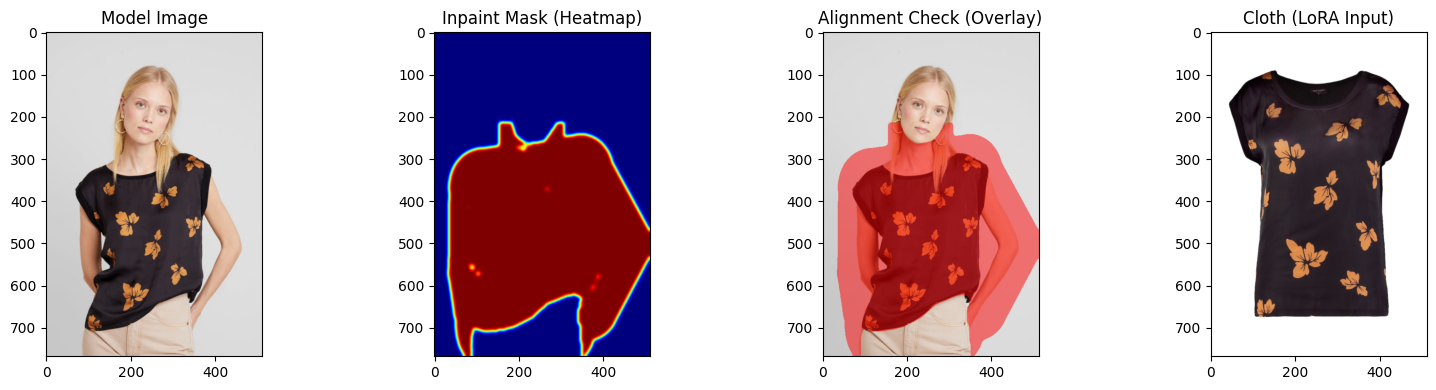


BẮT ĐẦU CHECK MODEL COMPATIBILITY
Kích thước Latent: torch.Size([1, 4, 96, 64])
Kích thước UNet Input: torch.Size([1, 9, 96, 64])
CHUẨN: UNet đã sẵn sàng cho Inpainting (9 kênh).
Hệ thống đã pass.


In [3]:
from torch.utils.data import DataLoader

TRAIN_CSV = "/kaggle/input/datasets/cthnhoddt/dlp-cleandatacsv/clean_vto_dataset_train.csv" 
TRAIN_CAPTION_DIR = "/kaggle/input/datasets/cthnhoddt/dlp-cloth-caption/cloth-captions/train"
ROOT_DIR = "/kaggle/input/datasets/marquis03/high-resolution-viton-zalando-dataset/train"

# Khởi tạo Dataset (Bật strict_check để rà soát lỗi rủi ro)
print("Đang khởi tạo Dataset...")
train_dataset = StableDiffusionInpaintPreprocess(
    csv_path=TRAIN_CSV,
    root_dir=ROOT_DIR,
    caption_dir=TRAIN_CAPTION_DIR,
    target_size=(768, 512),
    trigger_word="hyeiu_cloth",
    strict_check=True  
)

# Khởi tạo DataLoader (Lấy batch_size=1 để vẽ 1 mẫu lên xem cho rõ)
train_loader = DataLoader(
    train_dataset,
    batch_size=1,       
    shuffle=True,       # Lấy ngẫu nhiên 1 người mẫu trong tập 9000 ảnh
    num_workers=0
)

import torch
from diffusers import AutoencoderKL, UNet2DConditionModel

# Tải mô hình Stable Diffusion Inpainting 
print("⏳ Đang tải VAE và UNet từ HuggingFace (Chỉ chạy 1 lần)...")
model_id = "runwayml/stable-diffusion-inpainting"

# Dùng float16 để tiết kiệm VRAM trên Kaggle
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae", torch_dtype=torch.float16)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16)

# 2. Khởi tạo bộ kiểm định
checker = SanityCheck(device="cuda" if torch.cuda.is_available() else "cpu")

# BƯỚC 1: Kiểm tra File Hệ thống (Text Preflight Check)
is_files_ok = checker.run_text_preflight_check(TRAIN_CSV, TRAIN_CAPTION_DIR)

if is_files_ok:
    # BƯỚC 2: Kiểm tra Tensor & Hiển thị ảnh (Data Pipeline Check)
    sample_batch = checker.check_data_pipeline(train_loader, visualize=True)    
    # BƯỚC 3: Kiểm tra tương thích Mô hình (Model Compatibility Check)
    # Đưa batch dữ liệu giả lập qua VAE và kiểm tra xem UNet có nhận đúng 9 kênh không
    is_model_ok = checker.check_model_compatibility(unet, vae, sample_batch)
    
    if is_model_ok:
        print("Hệ thống đã pass.")
    else:
        print("Lỗi tương thích mô hình.")
        
else:
    print("\nThiếu file dữ liệu.")

# Dọn dẹp RAM/VRAM sau khi test xong để dành chỗ cho quá trình Train thật
del sample_batch
torch.cuda.empty_cache()

## Sanity Check cho dữ liệu trong tập test


BẮT ĐẦU CHECK FILE: test
Đang đối chiếu 1661 cloth_id từ CSV với thư mục 'test'...
BÁO CÁO: 1661/1661 file hợp lệ.

BẮT ĐẦU CHECK DATA TENSOR
Key: image        | Shape: [1, 3, 768, 512] | Range: [-1.00, 1.00]
Key: agnostic     | Shape: [1, 3, 768, 512] | Range: [-1.00, 0.97]
Key: cloth        | Shape: [1, 3, 768, 512] | Range: [-0.96, 1.00]
Key: inpaint_mask | Shape: [1, 1, 768, 512] | Range: [0.00, 1.00]
Key: input_ids    | Shape: [1, 77] | Type: torch.int64
Key: caption      | Value: 'hyeiu_cloth, a professional studio photo of womens floral print long sleeve crop top'


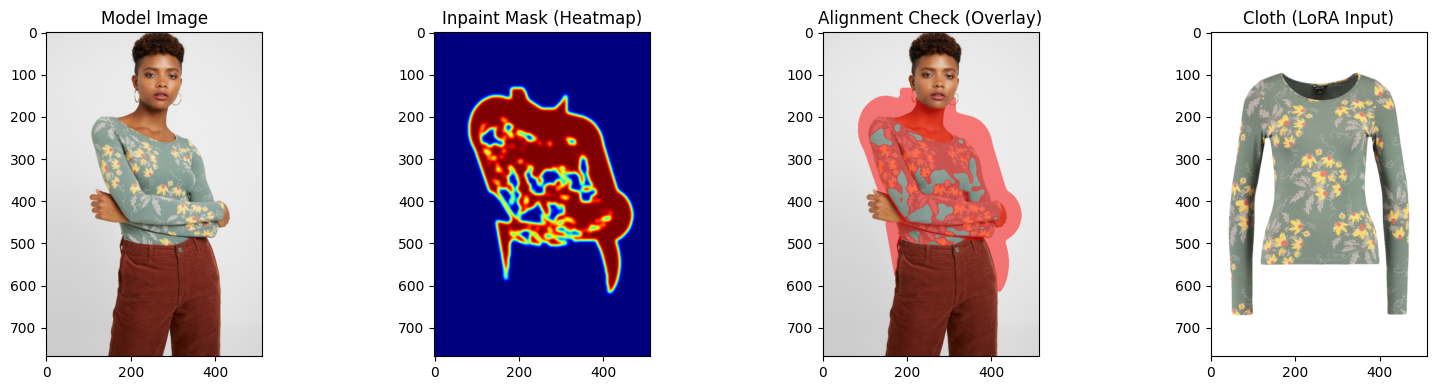


BẮT ĐẦU CHECK MODEL COMPATIBILITY
Kích thước Latent: torch.Size([1, 4, 96, 64])
Kích thước UNet Input: torch.Size([1, 9, 96, 64])
CHUẨN: UNet đã sẵn sàng cho Inpainting (9 kênh).

HOÀN TẤT: Tập dữ liệu TEST đã sẵn sàng để Inference!


In [4]:
from torch.utils.data import DataLoader

# 1. CẤU HÌNH ĐƯỜNG DẪN TẬP TEST
TEST_CSV = "/kaggle/input/datasets/cthnhoddt/dlp-cleandatacsv/clean_vto_dataset_test.csv" 
TEST_CAPTION_DIR = "/kaggle/input/datasets/cthnhoddt/dlp-cloth-caption/cloth-captions/test"
ROOT_DIR_TEST = "/kaggle/input/datasets/marquis03/high-resolution-viton-zalando-dataset/test"

# 2. KHỞI TẠO DATASET & DATALOADER TEST
# Tập test thường dùng để Inference nên để batch_size=1
test_dataset = StableDiffusionInpaintPreprocess(
    csv_path=TEST_CSV,
    root_dir=ROOT_DIR_TEST,
    caption_dir=TEST_CAPTION_DIR,
    target_size=(768, 512),
    trigger_word="hyeiu_cloth",
    strict_check=True,  # Bật kiểm tra nghiêm ngặt cho tập test,
    test_flag=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True, # Tập test nên để False để kiểm tra theo thứ tự nếu cần
    num_workers=0   # Để 0 khi chạy trên Notebook để tránh lỗi hiển thị
)

# 3. THỰC HIỆN KIỂM ĐỊNH 3 BƯỚC
checker_test = SanityCheck(device="cuda" if torch.cuda.is_available() else "cpu")

# BƯỚC 1: Kiểm tra Preflight (File tồn tại và không rỗng)
# Với tập test, ta bật is_test_pairs=True 
is_test_files_ok = checker_test.run_text_preflight_check(
    TEST_CSV, 
    TEST_CAPTION_DIR, 
    is_test_pairs=True 
)

if is_test_files_ok:
    # BƯỚC 2: Kiểm tra Pipeline dữ liệu 
    sample_test_batch = checker_test.check_data_pipeline(test_loader, visualize=True)
    
    # BƯỚC 3: Kiểm tra tương thích với UNet & VAE
    # Đảm bảo UNet 9 kênh nhận diện đúng dữ liệu tập test
    is_test_model_ok = checker_test.check_model_compatibility(unet, vae, sample_test_batch)
    
    if is_test_model_ok:
        print("\nHOÀN TẤT: Tập dữ liệu TEST đã sẵn sàng để Inference!")
    else:
        print("\nDữ liệu Test không tương thích với cấu trúc mô hình.")
else:
    print("\nThiếu file dữ liệu hoặc caption rỗng trong tập TEST.")

# Dọn dẹp bộ nhớ
if 'sample_test_batch' in locals(): del sample_test_batch
torch.cuda.empty_cache()

## Chạy thử một vài mẫu

--- BẮT ĐẦU BENCHMARK (10 mẫu) ---


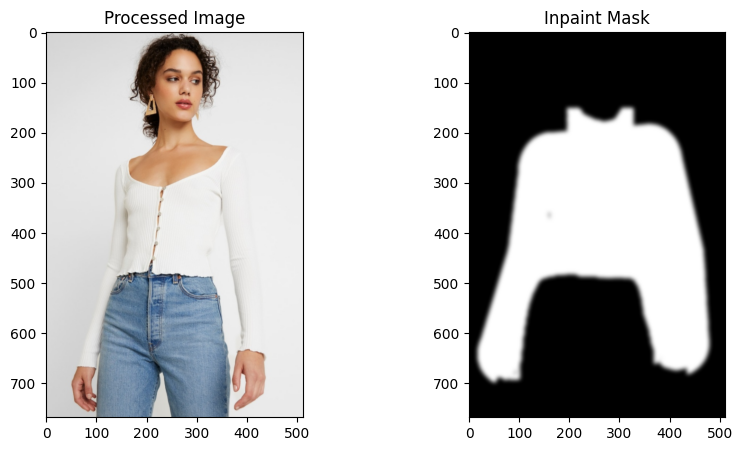

VRAM chiếm dụng cho 1 batch (2 mẫu): 16.50 MB
--- KẾT QUẢ ---
Tổng thời gian xử lý: 2.4470 giây
Trung bình mỗi mẫu: 0.2447 giây/sample
Tốc độ: 4.09 samples/giây
VRAM Peak: 2405.29 MB


In [5]:
import time
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

def benchmark_preprocessing(dataset, num_samples=10, batch_size=2, device="cuda"):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    print(f"--- BẮT ĐẦU BENCHMARK ({num_samples} mẫu) ---")
    
    # Đo thời gian
    start_time = time.time()
    
    # Khởi tạo thông số VRAM ban đầu
    if device == "cuda":
        torch.cuda.empty_cache()
        initial_vram = torch.cuda.memory_allocated(device) / (1024**2)
    
    samples_processed = 0
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if samples_processed >= num_samples:
                break
                
            # Đưa các tensor quan trọng lên GPU để giả lập training loop
            image = batch["image"].to(device, dtype=torch.float16)
            mask = batch["inpaint_mask"].to(device, dtype=torch.float16)
            cloth = batch["cloth"].to(device)
            mask = batch["inpaint_mask"].to(device)
            input_ids = batch["input_ids"].to(device)

            if i == 0:
                # Lấy mẫu đầu tiên của batch đầu tiên để xem thử
                img_to_show = batch["image"][0].permute(1, 2, 0).cpu().numpy()
                img_to_show = (img_to_show * 0.5 + 0.5).clip(0, 1) # Đưa từ [-1, 1] về [0, 1]
                
                mask_to_show = batch["inpaint_mask"][0].squeeze().cpu().numpy()
                
                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1); plt.imshow(img_to_show); plt.title("Processed Image")
                plt.subplot(1, 2, 2); plt.imshow(mask_to_show, cmap='gray'); plt.title("Inpaint Mask")
                plt.show()
            
            samples_processed += batch_size
            
            if i == 0 and device == "cuda":
                # Kiểm tra VRAM sau khi load batch đầu tiên
                current_vram = torch.cuda.memory_allocated(device) / (1024**2)
                print(f"VRAM chiếm dụng cho 1 batch ({batch_size} mẫu): {current_vram - initial_vram:.2f} MB")

    end_time = time.time()
    total_time = end_time - start_time
    
    print(f"--- KẾT QUẢ ---")
    print(f"Tổng thời gian xử lý: {total_time:.4f} giây")
    print(f"Trung bình mỗi mẫu: {total_time / samples_processed:.4f} giây/sample")
    print(f"Tốc độ: {samples_processed / total_time:.2f} samples/giây")
    
    if device == "cuda":
        print(f"VRAM Peak: {torch.cuda.max_memory_allocated(device) / (1024**2):.2f} MB")

    

# Khởi tạo dataset 
sdi_preprocessor = StableDiffusionInpaintPreprocess(
    csv_path="/kaggle/input/datasets/cthnhoddt/dlp-cleandatacsv/clean_vto_dataset_train.csv",
    root_dir="/kaggle/input/datasets/marquis03/high-resolution-viton-zalando-dataset/train",
    caption_dir="/kaggle/input/datasets/cthnhoddt/dlp-cloth-caption/cloth-captions/train"
)

benchmark_preprocessing(sdi_preprocessor, num_samples=10, batch_size=2)

## Overfitting Test

In [6]:
import torch
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer
import torch.nn.functional as FF
from torch.utils.data import DataLoader
from peft import LoraConfig, get_peft_model

def run_overfitting_test():
    model_id = "runwayml/stable-diffusion-inpainting"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- BƯỚC 1: KHỞI TẠO DATASET ---
    dataset = StableDiffusionInpaintPreprocess(
        csv_path="/kaggle/input/datasets/cthnhoddt/dlp-cleandatacsv/clean_vto_dataset_train.csv",
        root_dir="/kaggle/input/datasets/marquis03/high-resolution-viton-zalando-dataset/train",
        caption_dir="/kaggle/input/datasets/cthnhoddt/dlp-cloth-caption/cloth-captions/train",
        tokenizer_path=model_id,
        target_size=(768, 512),
        trigger_word="hyeiu_cloth",
        strict_check=True # Bật lên để check lỗi logic ngay từ đầu
    )

    # --- BƯỚC 2: LOAD CÁC THÀNH PHẦN MODEL ---
    print("Loading models...")
    tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
    # Load các thành phần nhẹ với float16 nếu có thể
    text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device, dtype=torch.float16)
    vae_model = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device, dtype=torch.float16)
    unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16).to(device)
    unet.enable_gradient_checkpointing() # Tiết kiệm VRAM cực lớn bằng cách tính toán lại activation
    noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

    # --- BƯỚC 3: CẤU HÌNH LORA ---
    # Inpainting UNet có 9 kênh đầu vào (4 latent + 1 mask + 4 agnostic)
    # LoRA sẽ bám vào các lớp Attention để học chi tiết cái áo
    lora_config = LoraConfig(
        r=16, 
        lora_alpha=16,
        target_modules=["to_q", "to_k", "to_v", "to_out.0"], # Các layer quan trọng trong Cross-Attention
        lora_dropout=0.05,
        bias="none"
    )
    unet = get_peft_model(unet, lora_config)

    # Đóng băng (freeze) các thành phần không train
    vae_model.requires_grad_(False)
    text_encoder.requires_grad_(False)
    unet.train()
    
    # Optimizer chỉ nhận các tham số có requires_grad=True (là các lớp LoRA)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, unet.parameters()), lr=1e-4)

    # --- BƯỚC 4: CHUẨN BỊ DATA (1 BATCH DUY NHẤT) ---
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    batch = next(iter(dataloader))
    
    print(f"--- Bắt đầu Overfit với LoRA trên {device} ---")

    # Đưa dữ liệu lên GPU
    pixel_values = batch["image"].to(device, dtype=torch.float16)
    mask_values = batch["inpaint_mask"].to(device, dtype=torch.float16)
    agnostic_values = batch["agnostic"].to(device, dtype=torch.float16)
    input_ids = batch["input_ids"].to(device)

    with torch.no_grad():
        # Encode sang latent 1 lần duy nhất
        latents = vae_model.encode(pixel_values).latent_dist.sample() * 0.18215
        agnostic_latents = vae_model.encode(agnostic_values).latent_dist.sample() * 0.18215
        mask_latent = FF.interpolate(mask_values, size=(96, 64), mode="bilinear") # bilinear tốt hơn cho inpaint
        encoder_hidden_states = text_encoder(input_ids)[0]

        # GIẢI PHÓNG VRAM CỰC ĐẠI: Xóa ảnh gốc vì đã có latent
        del pixel_values, agnostic_values, mask_values, vae_model, text_encoder
        torch.cuda.empty_cache()

    for epoch in range(300):
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 5. GHÉP CÁC KÊNH (Concatenate) - Đặc thù của SD Inpainting UNet
        # Nối theo chiều channel (dim=1): 4(noisy) + 1(mask) + 4(agnostic) = 9 channels
        latent_model_input = torch.cat([noisy_latents, mask_latent, agnostic_latents], dim=1)

        with torch.amp.autocast('cuda'):
            noise_pred = unet(latent_model_input.half(), timesteps, encoder_hidden_states.half()).sample
            loss = FF.mse_loss(noise_pred.float(), noise.float(), reduction="mean")
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

    print("Overfitting test hoàn tất!")

if __name__ == "__main__":
    run_overfitting_test()

Loading models...


config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

text_encoder/pytorch_model.bin:   0%|          | 0.00/492M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-inpainting
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpa

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

--- Bắt đầu Overfit với LoRA trên cuda ---
Epoch 000 | Loss: 0.036945
Epoch 020 | Loss: 0.024410
Epoch 040 | Loss: 0.313542
Epoch 060 | Loss: 0.277112
Epoch 080 | Loss: 0.058039
Epoch 100 | Loss: 0.016176
Epoch 120 | Loss: 0.183302
Epoch 140 | Loss: 0.228668
Epoch 160 | Loss: 0.028894
Epoch 180 | Loss: 0.063185
Epoch 200 | Loss: 0.178363
Epoch 220 | Loss: 0.001342
Epoch 240 | Loss: 0.004524
Epoch 260 | Loss: 0.023078
Epoch 280 | Loss: 0.529888
Overfitting test hoàn tất!


Dù Loss biến động, điều này tương đối bình thường với các mô hình Diffusion -> Overfitting Test đã pass.